In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

In [3]:
data = pd.read_csv("train.csv")

In [4]:
data

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,1199995,36.0,Female,27316.0,Married,0.0,Master's,Unemployed,13.772907,Urban,...,NaN,5.0,372.0,3.0,2023-05-03 15:21:39.257696,Poor,No,Daily,Apartment,1303.0
1199996,1199996,54.0,Male,35786.0,Divorced,NaN,Master's,Self-Employed,11.483482,Rural,...,NaN,10.0,597.0,4.0,2022-09-10 15:21:39.134960,Poor,No,Weekly,Apartment,821.0
1199997,1199997,19.0,Male,51884.0,Divorced,0.0,Master's,NaN,14.724469,Suburban,...,0.0,19.0,NaN,6.0,2021-05-25 15:21:39.106582,Good,No,Monthly,Condo,371.0
1199998,1199998,55.0,Male,NaN,Single,1.0,PhD,NaN,18.547381,Suburban,...,1.0,7.0,407.0,4.0,2021-09-19 15:21:39.190215,Poor,No,Daily,Apartment,596.0


In [5]:
data.describe()

,id,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,1.200000e+06,1.181295e+06,1.155051e+06,1.090328e+06,1.125924e+06,835971.000000,1.199994e+06,1.062118e+06,1.199999e+06,1.200000e+06
mean,5.999995e+05,4.114556e+01,3.274522e+04,2.009934e+00,2.561391e+01,1.002689,9.569889e+00,5.929244e+02,5.018219e+00,1.102545e+03
std,3.464103e+05,1.353995e+01,3.217951e+04,1.417338e+00,1.220346e+01,0.982840,5.776189e+00,1.499819e+02,2.594331e+00,8.649989e+02
min,0.000000e+00,1.800000e+01,1.000000e+00,0.000000e+00,2.012237e+00,0.000000,0.000000e+00,3.000000e+02,1.000000e+00,2.000000e+01
25%,2.999998e+05,3.000000e+01,8.001000e+03,1.000000e+00,1.591896e+01,0.000000,5.000000e+00,4.680000e+02,3.000000e+00,5.140000e+02
50%,5.999995e+05,4.100000e+01,2.391100e+04,2.000000e+00,2.457865e+01,1.000000,1.000000e+01,5.950000e+02,5.000000e+00,8.720000e+02
75%,8.999992e+05,5.300000e+01,4.463400e+04,3.000000e+00,3.452721e+01,2.000000,1.500000e+01,7.210000e+02,7.000000e+00,1.509000e+03
max,1.199999e+06,6.400000e+01,1.499970e+05,4.000000e+00,5.897591e+01,9.000000,1.900000e+01,8.490000e+02,9.000000e+00,4.999000e+03


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration    1199999 non-

In [7]:
data.drop(["id", "Policy Start Date", "Customer Feedback","Occupation"], axis = 1, inplace=True)

In [8]:
data

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,19.0,Female,10049.0,Married,1.0,Bachelor's,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,No,Weekly,House,2869.0
1,39.0,Female,31678.0,Divorced,3.0,Master's,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,Yes,Monthly,House,1483.0
2,23.0,Male,25602.0,Divorced,3.0,High School,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,Yes,Weekly,House,567.0
3,21.0,Male,141855.0,Married,2.0,Bachelor's,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,Yes,Daily,Apartment,765.0
4,21.0,Male,39651.0,Single,1.0,Bachelor's,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,Yes,Weekly,House,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,36.0,Female,27316.0,Married,0.0,Master's,13.772907,Urban,Premium,NaN,5.0,372.0,3.0,No,Daily,Apartment,1303.0
1199996,54.0,Male,35786.0,Divorced,NaN,Master's,11.483482,Rural,Comprehensive,NaN,10.0,597.0,4.0,No,Weekly,Apartment,821.0
1199997,19.0,Male,51884.0,Divorced,0.0,Master's,14.724469,Suburban,Basic,0.0,19.0,NaN,6.0,No,Monthly,Condo,371.0
1199998,55.0,Male,NaN,Single,1.0,PhD,18.547381,Suburban,Premium,1.0,7.0,407.0,4.0,No,Daily,Apartment,596.0


In [9]:
data.isnull().sum()

Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [10]:
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Annual Income'].fillna(data['Annual Income'].median(), inplace=True)
data['Marital Status'].fillna(data['Marital Status'].mode()[0], inplace=True)
data['Number of Dependents'].fillna(data['Number of Dependents'].mode()[0], inplace=True)
data['Health Score'].fillna(data['Health Score'].mean(), inplace=True)
data['Previous Claims'].fillna(0, inplace=True)
data['Vehicle Age'].fillna(data['Vehicle Age'].mode()[0], inplace=True)
data['Credit Score'].fillna(data['Credit Score'].mean(), inplace=True)
data['Insurance Duration'].fillna(data['Insurance Duration'].mean(), inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_7016\3201661549.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_7016\3201661549.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [11]:
data.isnull().sum()

Age                     0
Gender                  0
Annual Income           0
Marital Status          0
Number of Dependents    0
Education Level         0
Health Score            0
Location                0
Policy Type             0
Previous Claims         0
Vehicle Age             0
Credit Score            0
Insurance Duration      0
Smoking Status          0
Exercise Frequency      0
Property Type           0
Premium Amount          0
dtype: int64

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 17 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1200000 non-null  float64
 1   Gender                1200000 non-null  object 
 2   Annual Income         1200000 non-null  float64
 3   Marital Status        1200000 non-null  object 
 4   Number of Dependents  1200000 non-null  float64
 5   Education Level       1200000 non-null  object 
 6   Health Score          1200000 non-null  float64
 7   Location              1200000 non-null  object 
 8   Policy Type           1200000 non-null  object 
 9   Previous Claims       1200000 non-null  float64
 10  Vehicle Age           1200000 non-null  float64
 11  Credit Score          1200000 non-null  float64
 12  Insurance Duration    1200000 non-null  float64
 13  Smoking Status        1200000 non-null  object 
 14  Exercise Frequency    1200000 non-

In [13]:
data['Gender']= LabelEncoder().fit_transform(data['Gender'])
data['Marital Status']= LabelEncoder().fit_transform(data['Marital Status'])
data['Education Level']= LabelEncoder().fit_transform(data['Education Level'])
data['Location']= LabelEncoder().fit_transform(data['Location'])
data['Policy Type']= LabelEncoder().fit_transform(data['Policy Type'])
data['Smoking Status']= LabelEncoder().fit_transform(data['Smoking Status'])
data['Exercise Frequency']= LabelEncoder().fit_transform(data['Exercise Frequency'])
data['Property Type']= LabelEncoder().fit_transform(data['Property Type'])

In [14]:
data

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,19.0,0,10049.0,1,1.0,0,22.598761,2,2,2.0,17.0,372.00000,5.0,0,3,2,2869.0
1,39.0,0,31678.0,0,3.0,2,15.569731,0,1,1.0,12.0,694.00000,2.0,1,1,2,1483.0
2,23.0,1,25602.0,0,3.0,1,47.177549,1,2,1.0,14.0,592.92435,3.0,1,3,2,567.0
3,21.0,1,141855.0,1,2.0,0,10.938144,0,0,1.0,0.0,367.00000,1.0,1,0,0,765.0
4,21.0,1,39651.0,2,1.0,0,20.376094,0,2,0.0,8.0,598.00000,4.0,1,3,2,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,36.0,0,27316.0,1,0.0,2,13.772907,2,2,0.0,5.0,372.00000,3.0,0,0,0,1303.0
1199996,54.0,1,35786.0,0,3.0,2,11.483482,0,1,0.0,10.0,597.00000,4.0,0,3,0,821.0
1199997,19.0,1,51884.0,0,0.0,2,14.724469,1,0,0.0,19.0,592.92435,6.0,0,1,1,371.0
1199998,55.0,1,23911.0,2,1.0,3,18.547381,1,2,1.0,7.0,407.00000,4.0,0,0,0,596.0


In [23]:
x = data.drop("Premium Amount", axis=1)
y = data["Premium Amount"]

In [24]:
x

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,Property Type
0,19.0,0,10049.0,1,1.0,0,22.598761,2,2,2.0,17.0,372.00000,5.0,0,3,2
1,39.0,0,31678.0,0,3.0,2,15.569731,0,1,1.0,12.0,694.00000,2.0,1,1,2
2,23.0,1,25602.0,0,3.0,1,47.177549,1,2,1.0,14.0,592.92435,3.0,1,3,2
3,21.0,1,141855.0,1,2.0,0,10.938144,0,0,1.0,0.0,367.00000,1.0,1,0,0
4,21.0,1,39651.0,2,1.0,0,20.376094,0,2,0.0,8.0,598.00000,4.0,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,36.0,0,27316.0,1,0.0,2,13.772907,2,2,0.0,5.0,372.00000,3.0,0,0,0
1199996,54.0,1,35786.0,0,3.0,2,11.483482,0,1,0.0,10.0,597.00000,4.0,0,3,0
1199997,19.0,1,51884.0,0,0.0,2,14.724469,1,0,0.0,19.0,592.92435,6.0,0,1,1
1199998,55.0,1,23911.0,2,1.0,3,18.547381,1,2,1.0,7.0,407.00000,4.0,0,0,0


In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2 , train_size=20000, random_state=42) 

In [26]:
#scaling the dataset - to get to all same scale
scalling = StandardScaler()
x_train_scaled = scalling.fit_transform(x_train)
x_test_scaled = scalling.fit_transform(x_test)

In [27]:
#k values
error_rate = []

k_range = range(1, 21)
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    prediction = knn.predict(x_test_scaled)
    error = np.mean(prediction != y_test)
    error_rate.append(error)

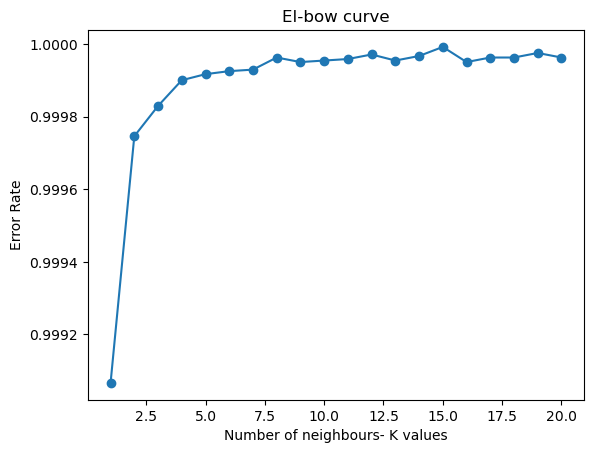

In [28]:
#plot the elbow curve
plt.plot(k_range, error_rate, marker = "o")
plt.title("El-bow curve")
plt.xlabel("Number of neighbours- K values")
plt.ylabel("Error Rate")
plt.show()

In [29]:
optimal_k = k_range[np.argmax(error_rate)]  #2
print(optimal_k)

15


# Model Creation

In [30]:
knn_final = KNeighborsRegressor(n_neighbors=1)  #2
knn_final.fit(x_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=1)

In [31]:
y_pred = knn_final.predict(x_test_scaled)

In [32]:
y_pred

array([ 763.,  671.,  837., ..., 1885., 1209., 2979.])

In [36]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("RMSE:", rmse)


R² Score: -0.9498455067317522
RMSE: 1207.1004276156975


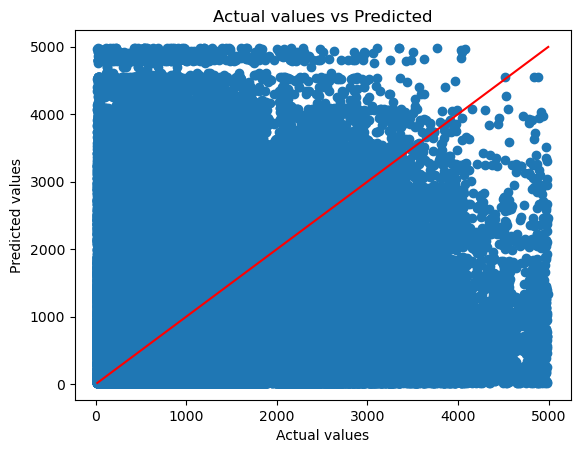

In [37]:
#plot the actual and pedicted
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color = 'red')
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual values vs Predicted")
plt.show()